<a href="https://colab.research.google.com/github/NannapatVis/Educare-Practice/blob/main/Train_TextToIMG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ใช้ Google Drive เป็นตัวเก็บข้อมูล**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##**แตกไฟล์ ZIP จาก Google Drive**

In [2]:
# Step 2: แตกไฟล์ ZIP
import zipfile
import os
import shutil

# ระบุพาธไปยังไฟล์ ZIP ใน Google Drive
zip_path = '/content/drive/MyDrive/picture.zip'

# กำหนดพาธสำหรับการแตกไฟล์ ZIP
extract_folder = '/content/data'

# ลบโฟลเดอร์เก่า (ถ้ามี) เพื่อแน่ใจว่าไม่มีไฟล์เก่า
if os.path.exists(extract_folder):
    shutil.rmtree(extract_folder)

# สร้างโฟลเดอร์สำหรับเก็บข้อมูลที่แตกออกมาใหม่
os.makedirs(extract_folder, exist_ok=True)

# แตกไฟล์ ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("การแตกไฟล์ ZIP เสร็จสิ้น")

# ตรวจสอบโครงสร้างของโฟลเดอร์ที่แตกไฟล์
for root, dirs, files in os.walk(extract_folder):
    print(root, len(dirs), len(files))

การแตกไฟล์ ZIP เสร็จสิ้น
/content/data 2 0
/content/data/musemart 1 0
/content/data/musemart/dataset_updated 2 0
/content/data/musemart/dataset_updated/training_set 5 0
/content/data/musemart/dataset_updated/training_set/drawings 0 162
/content/data/musemart/dataset_updated/training_set/sculpture 0 473
/content/data/musemart/dataset_updated/training_set/iconography 0 681
/content/data/musemart/dataset_updated/training_set/painting 0 2264
/content/data/musemart/dataset_updated/training_set/engraving 0 248
/content/data/musemart/dataset_updated/validation_set 5 0
/content/data/musemart/dataset_updated/validation_set/drawings 0 17
/content/data/musemart/dataset_updated/validation_set/sculpture 0 52
/content/data/musemart/dataset_updated/validation_set/iconography 0 75
/content/data/musemart/dataset_updated/validation_set/painting 0 100
/content/data/musemart/dataset_updated/validation_set/engraving 0 27
/content/data/dataset 1 0
/content/data/dataset/dataset_updated 2 0
/content/data/data

In [3]:
# Step 3: ตรวจสอบและลบไฟล์รูปภาพที่เสียหาย
from PIL import Image

def find_corrupted_images(directory):
    corrupted_files = []
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')  # เพิ่มนามสกุลที่ต้องการ
    for root, _, files in os.walk(directory):
        for file in files:
            if not file.lower().endswith(valid_extensions):
                print(f'ไฟล์ที่ไม่ใช่รูปภาพ: {os.path.join(root, file)}')
                corrupted_files.append(os.path.join(root, file))
                continue
            file_path = os.path.join(root, file)
            try:
                img = Image.open(file_path)
                img.verify()
            except (IOError, SyntaxError, Image.UnidentifiedImageError) as e:
                print(f'พบไฟล์ที่เสียหาย: {file_path} เนื่องจาก {e}')
                corrupted_files.append(file_path)
    return corrupted_files

def delete_files(file_list):
    for file_path in file_list:
        try:
            os.remove(file_path)
            print(f'ลบไฟล์: {file_path}')
        except Exception as e:
            print(f'ไม่สามารถลบไฟล์: {file_path} เนื่องจาก {e}')

# ระบุพาธไปยัง training_set และ validation_set
training_dir = '/content/data/combined_dataset/training_set'
validation_dir = '/content/data/combined_dataset/validation_set'

# ตรวจสอบและลบไฟล์ที่เสียหายใน training_set
print("กำลังตรวจสอบไฟล์ใน training_set...")
corrupted_train = find_corrupted_images(training_dir)
print(f'พบไฟล์ที่เสียหายใน training_set: {len(corrupted_train)} ไฟล์')
delete_files(corrupted_train)

# ตรวจสอบและลบไฟล์ที่เสียหายใน validation_set
print("กำลังตรวจสอบไฟล์ใน validation_set...")
corrupted_val = find_corrupted_images(validation_dir)
print(f'พบไฟล์ที่เสียหายใน validation_set: {len(corrupted_val)} ไฟล์')
delete_files(corrupted_val)

# ตรวจสอบอีกครั้งว่าไม่มีไฟล์ที่เสียหายเหลืออยู่
print("กำลังตรวจสอบไฟล์อีกครั้งใน training_set...")
corrupted_train = find_corrupted_images(training_dir)
print(f'พบไฟล์ที่เสียหายใน training_set: {len(corrupted_train)} ไฟล์')

print("กำลังตรวจสอบไฟล์อีกครั้งใน validation_set...")
corrupted_val = find_corrupted_images(validation_dir)
print(f'พบไฟล์ที่เสียหายใน validation_set: {len(corrupted_val)} ไฟล์')

กำลังตรวจสอบไฟล์ใน training_set...
พบไฟล์ที่เสียหายใน training_set: 0 ไฟล์
กำลังตรวจสอบไฟล์ใน validation_set...
พบไฟล์ที่เสียหายใน validation_set: 0 ไฟล์
กำลังตรวจสอบไฟล์อีกครั้งใน training_set...
พบไฟล์ที่เสียหายใน training_set: 0 ไฟล์
กำลังตรวจสอบไฟล์อีกครั้งใน validation_set...
พบไฟล์ที่เสียหายใน validation_set: 0 ไฟล์


In [4]:
# Step 4: รวมชุดข้อมูลจากหลายแหล่ง
import shutil

# สร้างโฟลเดอร์สำหรับชุดข้อมูลที่รวมกัน
combined_train = '/content/data/combined_dataset/training_set'
combined_val = '/content/data/combined_dataset/validation_set'

os.makedirs(combined_train, exist_ok=True)
os.makedirs(combined_val, exist_ok=True)

# รายการคลาส
classes = ['engraving', 'painting', 'iconography', 'sculpture', 'drawings']

# รวม training_set
for cls in classes:
    src_train_dataset = f'/content/data/dataset/dataset_updated/training_set/{cls}'
    src_train_musemart = f'/content/data/musemart/dataset_updated/training_set/{cls}'
    dst_train = f'{combined_train}/{cls}'
    os.makedirs(dst_train, exist_ok=True)

    # คัดลอกไฟล์จาก dataset
    if os.path.exists(src_train_dataset):
        for filename in os.listdir(src_train_dataset):
            src_file = os.path.join(src_train_dataset, filename)
            dst_file = os.path.join(dst_train, filename)
            if os.path.isfile(src_file):
                shutil.copy(src_file, dst_file)

    # คัดลอกไฟล์จาก musemart
    if os.path.exists(src_train_musemart):
        for filename in os.listdir(src_train_musemart):
            src_file = os.path.join(src_train_musemart, filename)
            dst_file = os.path.join(dst_train, filename)
            if os.path.isfile(src_file):
                shutil.copy(src_file, dst_file)

# รวม validation_set
for cls in classes:
    src_val_dataset = f'/content/data/dataset/dataset_updated/validation_set/{cls}'
    src_val_musemart = f'/content/data/musemart/dataset_updated/validation_set/{cls}'
    dst_val = f'{combined_val}/{cls}'
    os.makedirs(dst_val, exist_ok=True)

    # คัดลอกไฟล์จาก dataset
    if os.path.exists(src_val_dataset):
        for filename in os.listdir(src_val_dataset):
            src_file = os.path.join(src_val_dataset, filename)
            dst_file = os.path.join(dst_val, filename)
            if os.path.isfile(src_file):
                shutil.copy(src_file, dst_file)

    # คัดลอกไฟล์จาก musemart
    if os.path.exists(src_val_musemart):
        for filename in os.listdir(src_val_musemart):
            src_file = os.path.join(src_val_musemart, filename)
            dst_file = os.path.join(dst_val, filename)
            if os.path.isfile(src_file):
                shutil.copy(src_file, dst_file)

print("การรวมชุดข้อมูลเสร็จสิ้น")

การรวมชุดข้อมูลเสร็จสิ้น


In [5]:
# Step 5: เตรียมข้อมูลสำหรับการฝึกโมเดล
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# กำหนดพาธไปยังโฟลเดอร์ที่เก็บข้อมูลที่รวมกัน
train_dir = '/content/data/combined_dataset/training_set'
validation_dir = '/content/data/combined_dataset/validation_set'

# สร้าง ImageDataGenerator สำหรับการขยายข้อมูลและการปรับขนาด
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1./255)

# โหลดข้อมูลจากโฟลเดอร์
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),  # ปรับขนาดตามที่ต้องการ
    batch_size=32,
    class_mode='categorical'  # ใช้ 'categorical' สำหรับหลายคลาส
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

# ตรวจสอบว่าไม่มีไฟล์ที่มีปัญหาใน ImageDataGenerator
import tensorflow as tf

def find_problematic_files(generator):
    problematic_files = []
    for i in range(len(generator.filenames)):
        try:
            # พยายามโหลดรูปภาพ
            img_path = os.path.join(generator.directory, generator.filenames[i])
            img = tf.keras.preprocessing.image.load_img(img_path, target_size=(150, 150))
        except Exception as e:
            print(f'พบไฟล์ที่มีปัญหา: {img_path} เนื่องจาก {e}')
            problematic_files.append(img_path)
    return problematic_files

# ตรวจสอบไฟล์ใน training_set
print("กำลังตรวจสอบไฟล์ใน training_set ผ่าน ImageDataGenerator...")
problem_files_train = find_problematic_files(train_generator)
print(f'พบไฟล์ที่มีปัญหาใน training_set: {len(problem_files_train)} ไฟล์')
delete_files(problem_files_train)

# ตรวจสอบไฟล์ใน validation_set
print("กำลังตรวจสอบไฟล์ใน validation_set ผ่าน ImageDataGenerator...")
problem_files_val = find_problematic_files(validation_generator)
print(f'พบไฟล์ที่มีปัญหาใน validation_set: {len(problem_files_val)} ไฟล์')
delete_files(problem_files_val)

# ตรวจสอบอีกครั้งหลังจากลบไฟล์ที่มีปัญหา
print("กำลังตรวจสอบไฟล์อีกครั้งใน training_set...")
corrupted_train = find_corrupted_images(training_dir)
print(f'พบไฟล์ที่เสียหายใน training_set: {len(corrupted_train)} ไฟล์')
delete_files(corrupted_train)

print("กำลังตรวจสอบไฟล์อีกครั้งใน validation_set...")
corrupted_val = find_corrupted_images(validation_dir)
print(f'พบไฟล์ที่เสียหายใน validation_set: {len(corrupted_val)} ไฟล์')
delete_files(corrupted_val)

Found 8296 images belonging to 5 classes.
Found 1123 images belonging to 5 classes.
กำลังตรวจสอบไฟล์ใน training_set ผ่าน ImageDataGenerator...
พบไฟล์ที่มีปัญหา: /content/data/combined_dataset/training_set/engraving/249.jpg เนื่องจาก cannot identify image file <_io.BytesIO object at 0x7dd18cd79580>
พบไฟล์ที่มีปัญหา: /content/data/combined_dataset/training_set/engraving/304.jpg เนื่องจาก cannot identify image file <_io.BytesIO object at 0x7dd22d3dcc70>
พบไฟล์ที่มีปัญหา: /content/data/combined_dataset/training_set/engraving/356.jpg เนื่องจาก cannot identify image file <_io.BytesIO object at 0x7dd18e24aa20>
พบไฟล์ที่มีปัญหา: /content/data/combined_dataset/training_set/iconography/331.jpg เนื่องจาก cannot identify image file <_io.BytesIO object at 0x7dd22d3dcc70>
พบไฟล์ที่มีปัญหา: /content/data/combined_dataset/training_set/iconography/69.jpg เนื่องจาก cannot identify image file <_io.BytesIO object at 0x7dd18e24aa20>
พบไฟล์ที่มีปัญหา: /content/data/combined_dataset/training_set/painting/000

/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


พบไฟล์ที่มีปัญหา: /content/data/combined_dataset/training_set/sculpture/374.jpg เนื่องจาก cannot identify image file <_io.BytesIO object at 0x7dd18cc58ea0>
พบไฟล์ที่มีปัญหาใน training_set: 108 ไฟล์
ลบไฟล์: /content/data/combined_dataset/training_set/engraving/249.jpg
ลบไฟล์: /content/data/combined_dataset/training_set/engraving/304.jpg
ลบไฟล์: /content/data/combined_dataset/training_set/engraving/356.jpg
ลบไฟล์: /content/data/combined_dataset/training_set/iconography/331.jpg
ลบไฟล์: /content/data/combined_dataset/training_set/iconography/69.jpg
ลบไฟล์: /content/data/combined_dataset/training_set/painting/0000.jpg
ลบไฟล์: /content/data/combined_dataset/training_set/painting/0025.jpg
ลบไฟล์: /content/data/combined_dataset/training_set/painting/0050.jpg
ลบไฟล์: /content/data/combined_dataset/training_set/painting/0075.jpg
ลบไฟล์: /content/data/combined_dataset/training_set/painting/0125.jpg
ลบไฟล์: /content/data/combined_dataset/training_set/painting/0150.jpg
ลบไฟล์: /content/data/combine

In [6]:
# Step 6: สร้างและคอมไพล์โมเดล CNN
from tensorflow.keras import layers, models

# จำนวนคลาส (ปรับตามที่คุณมี)
num_classes = 5  # เช่น engraving, painting, iconography, sculpture, drawings

# สร้างโมเดล CNN
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dense(num_classes, activation='softmax')  # ใช้ 'softmax' สำหรับหลายคลาส
])

# แสดงสรุปโมเดล
model.summary()

# คอมไพล์โมเดล
model.compile(
    loss='categorical_crossentropy',  # ใช้สำหรับหลายคลาส
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 15, 15, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       3,211,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │           2,565 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,455,173 (13.18 MB)

 Trainable params: 3,455,173 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Step 7: ฝึกโมเดล
# Before fitting the model, regenerate the training and validation generators
# to ensure they reflect any changes to the dataset after cleaning.
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),  # ปรับขนาดตามที่ต้องการ
    batch_size=32,
    class_mode='categorical'  # ใช้ 'categorical' สำหรับหลายคลาส
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=30,  # ปรับตามต้องการ
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size)

Found 8188 images belonging to 5 classes.
Found 1107 images belonging to 5 classes.
Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


240/255 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.5546 - loss: 1.1017

/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


255/255 ━━━━━━━━━━━━━━━━━━━━ 479s 2s/step - accuracy: 0.5600 - loss: 1.0912 - val_accuracy: 0.7040 - val_loss: 0.8774
Epoch 2/30
  1/255 ━━━━━━━━━━━━━━━━━━━━ 5:37 1s/step - accuracy: 0.6875 - loss: 0.8513

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 914us/step - accuracy: 0.6875 - loss: 0.8513 - val_accuracy: 0.7895 - val_loss: 0.6949
Epoch 3/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 500s 2s/step - accuracy: 0.7237 - loss: 0.7612 - val_accuracy: 0.6664 - val_loss: 0.9050
Epoch 4/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 962us/step - accuracy: 0.7188 - loss: 0.7522 - val_accuracy: 0.7895 - val_loss: 0.5066
Epoch 5/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 469s 2s/step - accuracy: 0.7499 - loss: 0.6957 - val_accuracy: 0.7638 - val_loss: 0.6498
Epoch 6/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 909us/step - accuracy: 0.6250 - loss: 1.0632 - val_accuracy: 0.7895 - val_loss: 0.6972
Epoch 7/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 471s 2s/step - accuracy: 0.7456 - loss: 0.6945 - val_accuracy: 0.7610 - val_loss: 0.6596
Epoch 8/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 2s 940us/step - accuracy: 0.7500 - loss: 0.5209 - val_accuracy: 0.7895 - val_loss: 0.6574
Epoch 9/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 467s 2s/step - accuracy: 0.7803 - loss: 0.6080 - val_accuracy: 0

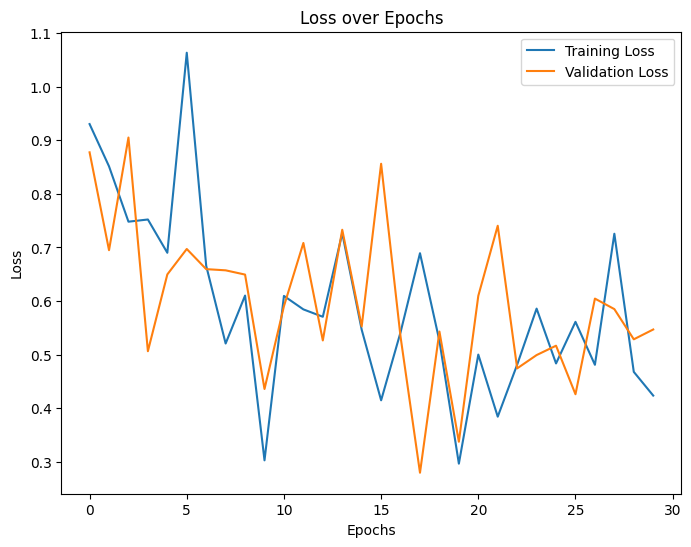

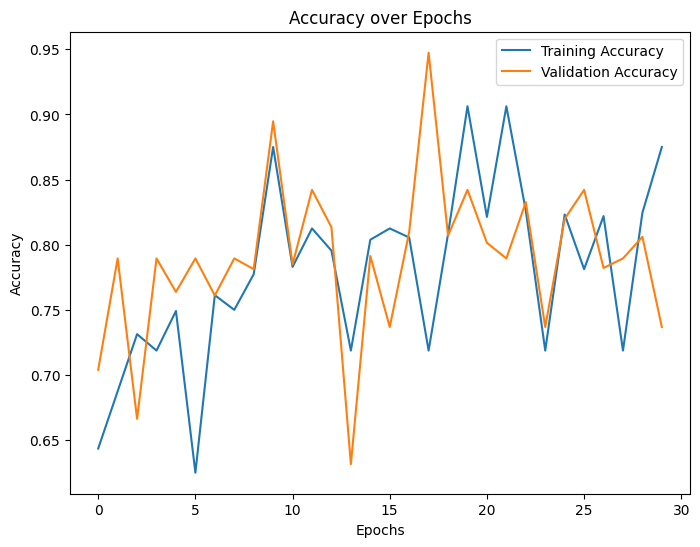

In [8]:
import matplotlib.pyplot as plt

# กราฟ Loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.show()

# กราฟ Accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.show()


In [12]:
loss, accuracy = model.evaluate(validation_generator)
print(f'Validation Loss: {loss}')
print(f'Validation Accuracy: {accuracy}')


35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 537ms/step - accuracy: 0.7874 - loss: 0.5625
Validation Loss: 0.5894237160682678
Validation Accuracy: 0.7841011881828308


In [20]:
# บันทึกโมเดล
model.save('/content/drive/MyDrive/my_cnn_model.h5')

In [25]:
from google.colab import files
uploaded = files.upload()  # อัปโหลดรูปภาพ


Saving 1 18.59.20.jpg to 1 18.59.20.jpg


In [26]:
from tensorflow.keras.preprocessing import image
import numpy as np

# ใช้ชื่อไฟล์จากการอัปโหลด
img_path = '1 18.59.20.jpg'  # ใช้ชื่อไฟล์ที่อัปโหลดจริง ๆ
img = image.load_img(img_path, target_size=(150, 150))  # ปรับขนาดรูปภาพให้เข้ากับโมเดล

# แปลงรูปภาพให้เป็น array และทำการปรับขนาด
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0  # ปรับขนาดข้อมูลให้เป็นช่วง 0-1

# ทำการทำนาย
prediction = model.predict(img_array)

# รายการคลาสที่คุณมี
classes = ['engraving', 'painting', 'iconography', 'sculpture', 'drawings']

# แปลงผลลัพธ์ให้เป็นคลาส
predicted_class = classes[np.argmax(prediction)]
print(f'รูปภาพนี้ถูกจำแนกว่าเป็น: {predicted_class}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
รูปภาพนี้ถูกจำแนกว่าเป็น: iconography


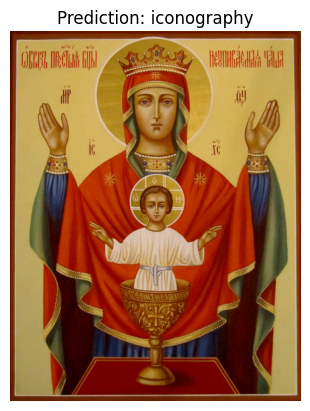

In [27]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# แสดงผลรูปภาพที่ทำนาย
img = mpimg.imread(img_path)
plt.imshow(img)
plt.title(f'Prediction: {predicted_class}')
plt.axis('off')  # ซ่อนแกน
plt.show()


In [28]:
evaluation = model.evaluate(validation_generator)
print(f'Validation Loss: {evaluation[0]}')
print(f'Validation Accuracy: {evaluation[1]}')


35/35 ━━━━━━━━━━━━━━━━━━━━ 24s 677ms/step - accuracy: 0.7773 - loss: 0.6047
Validation Loss: 0.5894237756729126
Validation Accuracy: 0.7841011881828308
